Stuart Rossiter, C00284845

# Licensing
Support Vector Machine using the Lung Cancer Clinical Dataset Copyright (C) 2025 Stuart Rossiter 
https://www.kaggle.com/datasets/zkskhurram/lung-cancer-clinical-dataset-20152025?select=lung_cancer_dataset.csv

This program is free software: you can redistribute it and/or modify it under the terms of the GNU General Public License as published by the Free Software Foundation, either version 3 of the License, or (at your option) any later version.

This program is distributed in the hope that it will be useful, but WITHOUT ANY WARRANTY; without even the implied warranty of MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the GNU General Public License for more details.

You should have received a copy of the GNU General Public License along with this program. If not, see https://www.gnu.org/licenses/.

# Support Vector Machine - Determining Lung Cancer Survival based on metrics.
Using Support Vector Machines (SVMs), I will be attempting to create a model to predict whether a lung cancer patient's cancer will metastasise, and whether they will survive their diagnosis.

# Preprocessing
First things first, the dataset needs to be imported.

In [ ]:
from sklearn import svm
from sklearn.model_selection import train_test_split
import pandas as pd

data = pd.read_csv("lung_cancer_dataset.csv")

Before we can get the appropriate columns from the dataset, we must encode all non numeric data that we plan to use. In addition, one hot encoding will be used for the non binary categorical data. This replaces the column with "dummy" columns, one for each possible value. Without this, if you were to encode the values "smoker", "former", "never", as 2, 1, 0, "smoker" would be twice "former", which doesn't make sense.

In [ ]:
binary_criteria = ["Family_History",
                   "Chronic_Lung_Disease",
                   "Asbestos_Exposure",
                   "Radon_Exposure",
                   "Previous_Cancer_History",
                   "Shortness_of_Breath",
                   "Chest_Pain",
                   "Coughing_Blood",
                   "Fatigue",
                   "Weight_Loss",
                   "Recurrent_Infections",
                   "Swallowing_Difficulty",
                   "Finger_Clubbing",
                   "Metastasis",
                   "Survived"]
for col in binary_criteria:
    data[col] = data[col].map({"Yes": 1, "No": 0})
data["Gender"] = data["Gender"].map({"Male": 1, "Female": 0})

criteria = ["Age", 
            "Gender", 
            "Smoking_Status",
            "Cigarettes_Per_Day",
            "Years_Smoking",
            "Family_History",
            "Alcohol_Use",
            "BMI",
            "Exercise_Frequency",
            "Chronic_Lung_Disease",
            "Asbestos_Exposure",
            "Radon_Exposure",
            "Previous_Cancer_History",
            "Shortness_of_Breath",
            "Chest_Pain",
            "Coughing_Blood",
            "Fatigue",
            "Weight_Loss",
            "Recurrent_Infections",
            "Swallowing_Difficulty",
            "Finger_Clubbing",
            "Tumor_Size_cm"]
metrics = data[criteria]
metrics = pd.get_dummies(metrics, columns=["Smoking_Status", "Alcohol_Use", "Exercise_Frequency"], drop_first=True)
meta_class = data["Metastasis"]
survival_class = data["Survived"]

Next, we split the data into a training/testing split, and create our base models.

In [ ]:
metastasis_SVM = svm.SVC()
survival_SVM = svm.SVC()
    
X_train, X_test, meta_train, meta_test, survival_train, survival_test = train_test_split(metrics, meta_class, survival_class, test_size=0.3, random_state=13)

While the categorical data has been encoded, all the data needs to be appropriately scaled, to give all categories equal impact.

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Fitting and Predictions
With our data formatted, and our base models created, it's finally time to fit the models and predict the metastasis and survival classes.

In [ ]:
metastasis_SVM.fit(X_train, meta_train)
survival_SVM.fit(X_train, survival_train)

pred_meta = metastasis_SVM.predict(X_test)
pred_surv = survival_SVM.predict(X_test)

With our predictions done, it's time to see how our models fared. First up, let's check the Metastasis class. We'll create a confusion matrix, and plot it using matplotlib's pyplot.

Text(113.9222222222222, 0.5, 'predicted label')

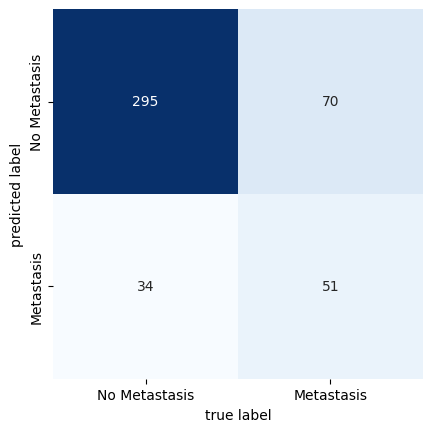

In [ ]:
import sklearn.metrics as mtc
import matplotlib.pyplot as plt
import seaborn as sb

matrix = mtc.confusion_matrix(meta_test, pred_meta, labels=[0, 1])

sb.heatmap(matrix.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=["No Metastasis", "Metastasis"], yticklabels=["No Metastasis", "Metastasis"],
            cmap='Blues')
plt.xlabel('true label')
plt.ylabel('predicted label')

That doesn't look quite right. Let's see how the Survived classification did.

Text(113.9222222222222, 0.5, 'predicted label')

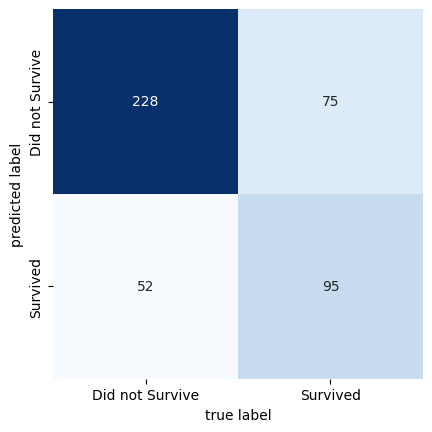

In [ ]:
matrix = mtc.confusion_matrix(survival_test, pred_surv, labels=[0, 1])

sb.heatmap(matrix.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=["Did not Survive", "Survived"], yticklabels=["Did not Survive", "Survived"],
            cmap='Blues')
plt.xlabel('true label')
plt.ylabel('predicted label')

# Tuning
Better than the Metastasis class, but not incredible. This can be remedied with some fine tuning of the model and the splitting of data. First and foremost, we need to resplit the data stratifying based on Metastasis and Survived. These new splits will have to be scaled once again.

In [ ]:
X_Meta_Tune_train, X_Meta_Tune_test, Meta_Tune_train, Meta_Tune_test = train_test_split(metrics, meta_class, test_size=0.3, random_state=13, stratify=meta_class)
X_Surv_Tune_train, X_Surv_Tune_test, Surv_Tune_train, Surv_Tune_test = train_test_split(metrics, survival_class, test_size=0.3, random_state=13, stratify=survival_class)

scaler = StandardScaler()
X_Meta_Tune_train = scaler.fit_transform(X_Meta_Tune_train)
X_Meta_Tune_test = scaler.transform(X_Meta_Tune_test)

X_Surv_Tune_train = scaler.fit_transform(X_Surv_Tune_train)
X_Surv_Tune_test = scaler.transform(X_Surv_Tune_test)

In addition to stratifying the data split, we can search for ideal tuning parameters for the model itself using GridSearchCV from SKLearn. We can set a parameter grid, wherein the GridSearchCV will test the model with all the parameter permutations, in an attempt to find the combination with the best scoring metric, which in this case will be the f1 score.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.1, 1, 5, 10],
    "gamma": ["scale", 0.01, 0.1, 0.5, 1],
    "kernel": ["rbf", "linear"],
    "class_weight": [None, "balanced"]
}

grid_meta = GridSearchCV(
    svm.SVC(),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_surv = GridSearchCV(
    svm.SVC(),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_meta.fit(X_Meta_Tune_train, Meta_Tune_train)
grid_surv.fit(X_Surv_Tune_train, Surv_Tune_train)

print("Best params (metastasis):", grid_meta.best_params_)
print("Best params (survived):", grid_surv.best_params_)

Best params (metastasis): {'C': 0.1, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'linear'}
Best params (survived): {'C': 0.1, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'linear'}


Now that we have the ideal parameter set, let's use these along with our split data on creating our new model. We'll display the metastasis confusion matrix first.

Text(113.9222222222222, 0.5, 'predicted label')

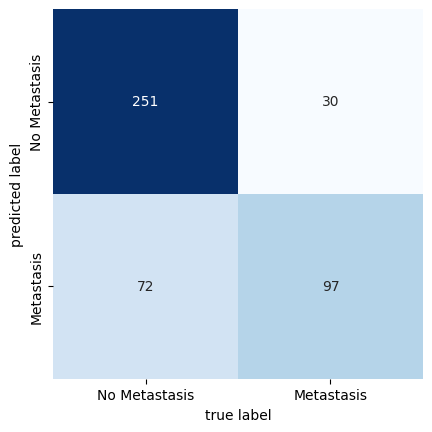

In [ ]:
tuned_metastasis_SVM = svm.SVC(C=grid_meta.best_params_["C"],
                               class_weight=grid_meta.best_params_["class_weight"],
                               gamma=grid_meta.best_params_["gamma"],
                               kernel=grid_meta.best_params_["kernel"])
tuned_survival_SVM = svm.SVC(C=grid_surv.best_params_["C"],
                               class_weight=grid_surv.best_params_["class_weight"],
                               gamma=grid_surv.best_params_["gamma"],
                               kernel=grid_surv.best_params_["kernel"])

tuned_metastasis_SVM.fit(X_Meta_Tune_train, Meta_Tune_train)
tuned_survival_SVM.fit(X_Surv_Tune_train, Surv_Tune_train)

tune_meta_pred = tuned_metastasis_SVM.predict(X_Meta_Tune_test)
tune_surv_pred = tuned_survival_SVM.predict(X_Surv_Tune_test)

matrix = mtc.confusion_matrix(Meta_Tune_test, tune_meta_pred, labels=[0, 1])

sb.heatmap(matrix.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=["No Metastasis", "Metastasis"], yticklabels=["No Metastasis", "Metastasis"],
            cmap='Blues')
plt.xlabel('true label')
plt.ylabel('predicted label')

Not perfect, but much better than before. Let's check the survived confusion matrix.

Text(113.9222222222222, 0.5, 'predicted label')

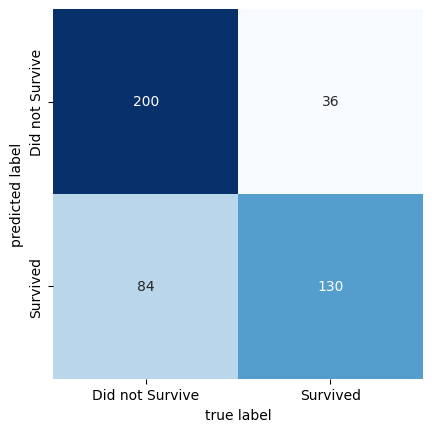

In [ ]:
matrix = mtc.confusion_matrix(Surv_Tune_test, tune_surv_pred, labels=[0, 1])

sb.heatmap(matrix.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=["Did not Survive", "Survived"], yticklabels=["Did not Survive", "Survived"],
            cmap='Blues')
plt.xlabel('true label')
plt.ylabel('predicted label')

It would seem that tuning the models has resulted in much better performance from them.

# Conclusion
While the models saw some improvement from tuning, it would still be unreasonable to consider them viable for any medical purposes. SVM seems like the wrong type of model for such a case, as the medical industry would require a high level of accuracy. From a learning standpoint, however, the effects of tuning a model have been displayed, confirming the importance of it.